<a href="https://colab.research.google.com/github/CesarAlejandroSoto/Alejandro/blob/main/ProyectoFinal_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌽 Proyecto Final - Modelo de IA para el diagnostico temprano de enfermedades en maiz a partir de imagenes de hojas

# Autores:
Cesar Alejandro Soto Paipa - 2225612

Emersson Elian Lopez Pita - 2225507

Juan David Mena Gamboa - 2221886

# Dataset: PlantVilalage
https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset

##  Descripción del Proyecto

Este proyecto implementa un sistema completo de inteligencia artificial para la detección automática de enfermedades en hojas de maíz utilizando el dataset **PlantVillage**. Combina múltiples enfoques de Machine Learning, Deep Learning y análisis no supervisado para crear una solución robusta y validada.

##  Objetivos Principales

- **Análisis Exploratorio**: Comprender y visualizar el dataset PlantVillage
- **Machine Learning Tradicional**: Implementar modelos con features simples (mean/std RGB)
- **Deep Learning**: Desarrollar un MLP personalizado para clasificación
- **Validación No Supervisada**: Usar clustering para validar las features aprendidas
- **Comparativa Integral**: Evaluar diferentes enfoques de IA



##  Metodología Implementada

### **Fase 1: Análisis Exploratorio**
- Estructura y distribución del dataset
- Visualización de imágenes por clase
- Análisis de dimensiones y estadísticas

### **Fase 2: Aprendizaje Supervisado**
- **Modelos ML**: Decision Tree, Random Forest, SVM
- **Deep Learning**: Con un modelo MLP
- **Evaluación**: Accuracy, matrices de confusión, curvas de aprendizaje

### **Fase 3: Aprendizaje No Supervisado**
- **Extracción de Features**: Capas profundas del MLP
- **Reducción Dimensional**: PCA (10 componentes), t-SNE (visualización)
- **Clustering**: KMeans, DBSCAN, Agglomerative Clustering
- **Validación**: Método del codo, métricas ARI y Silhouette


##  Tecnologías y Librerías

- **Lenguaje**: Python 3.x
- **ML Tradicional**: Scikit-learn, Pandas, NumPy
- **Deep Learning**: TensorFlow/Keras
- **Visualización**: Matplotlib, Seaborn
- **Entorno**: Google Colab

##  Resultados Esperados

- Modelos de ML con accuracy competitiva (>85%)
- MLP capaz de generalizar en nuevas imágenes
- Validación de que las features aprendidas son biológicamente relevantes
- Coherencia entre métodos supervisados y no supervisados
- Sistema integral para detección temprana de enfermedades


** Proyecto desarrollado como trabajo final de la materia de Inteligencia Artificial**

In [ ]:
# =========================
# 0) CONFIG / MOUNT DRIVE /
# =========================
from google.colab import drive
drive.mount('/content/drive')

ROOT_DRIVE = "/content/drive/MyDrive/PlantVillage"
DATA_COLOR = os.path.join(ROOT_DRIVE, "color")
print("DATA_COLOR expected:", DATA_COLOR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_COLOR expected: /content/drive/MyDrive/PlantVillage/color


# 1) Descarga alternativa vía kagglehub (opcional)



In [ ]:
# 1b) Intento de descarga si no existe (opcional)
if not os.path.isdir(DATA_COLOR):
    print("No se encontró la carpeta en Drive. Intentando descarga con kagglehub (si está disponible)...")
    try:
        import kagglehub
        path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
        print("Path to dataset files:", path)
        # intentar localizar carpeta "color" dentro del dataset descargado
        possible = os.path.join(path, "color")
        if os.path.isdir(possible):
            # copiar o montar según sea necesario (simple aviso)
            print("Encontrada carpeta 'color' en:", possible)
            print("Si quieres, copia manualmente a Drive o ajusta DATA_COLOR a esta ruta.")
        else:
            print("No se encontró carpeta 'color' dentro del dataset descargado. Revisa manualmente.")
    except Exception as e:
        print("kagglehub no disponible o fallo en descarga:", e)
        print("Por favor asegúrate de subir la carpeta PlantVillage/color a Drive o instala kagglehub.")
else:
    print("Carpeta encontrada en Drive; continuamos.")


Carpeta encontrada en Drive; continuamos.


# 2) Librerias Usadas


In [ ]:
# =========================
# LIBRERÍAS UNIFICADAS
# =========================

# Configuración y manejo de datos
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy

# Machine Learning tradicional
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.spatial.distance import cdist

# Deep Learning
import tensorflow as tf
import keras
from tensorflow.keras import Model, layers
from PIL import Image

# Configuración de estilo
sns.set(style="whitegrid")

# Reproducibilidad
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)


# 3) Analisis Estructural del dataset

In [ ]:

print("=== ANÁLISIS ESTRUCTURAL - DATASET PLANTVILLAGE ===")

# ESTRUCTURA DE CARPETAS
print("\n ESTRUCTURA DE CARPETAS:")
print(f"Ruta del dataset: {DATA_COLOR}")

# Verificar que todas las carpetas existan
print("\n VERIFICACIÓN DE CARPETAS:")
for clase in clases_corn:
    folder = os.path.join(DATA_COLOR, clase)
    existe = " EXISTE" if os.path.exists(folder) else " NO EXISTE"
    print(f"  {existe} - {clase}")

# CONTEO DE IMÁGENES POR CLASE
print("\n CONTEO DE IMÁGENES POR CLASE:")
clases_stats = []
total_imagenes = 0

for clase in clases_corn:
    folder = os.path.join(DATA_COLOR, clase)
    if os.path.exists(folder):
        archivos = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png','.jpeg'))]
        num_imagenes = len(archivos)
        clases_stats.append((clase, num_imagenes))
        total_imagenes += num_imagenes
        print(f"  {clase}: {num_imagenes} imágenes")

print(f"\n TOTAL DE IMÁGENES EN EL DATASET: {total_imagenes}")

df_resumen = pd.DataFrame(clases_stats, columns=['Clase', 'Número de Imágenes'])
df_resumen['Porcentaje'] = (df_resumen['Número de Imágenes'] / total_imagenes * 100).round(2)

=== ANÁLISIS ESTRUCTURAL - DATASET PLANTVILLAGE ===

 ESTRUCTURA DE CARPETAS:
Ruta del dataset: /content/drive/MyDrive/PlantVillage/color

 VERIFICACIÓN DE CARPETAS:
   EXISTE - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   EXISTE - Corn_(maize)___Common_rust_
   EXISTE - Corn_(maize)___Northern_Leaf_Blight
   EXISTE - Corn_(maize)___healthy

 CONTEO DE IMÁGENES POR CLASE:
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 imágenes
  Corn_(maize)___Common_rust_: 1192 imágenes
  Corn_(maize)___Northern_Leaf_Blight: 985 imágenes
  Corn_(maize)___healthy: 1162 imágenes

 TOTAL DE IMÁGENES EN EL DATASET: 3852


# 4) Distrubucion


=== VISUALIZACIÓN DE DISTRIBUCIÓN ===


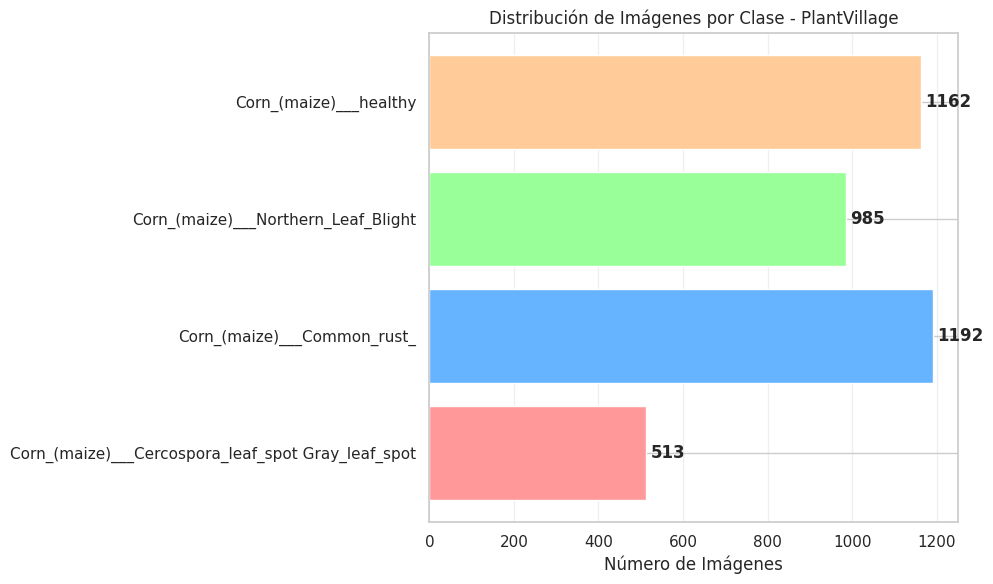

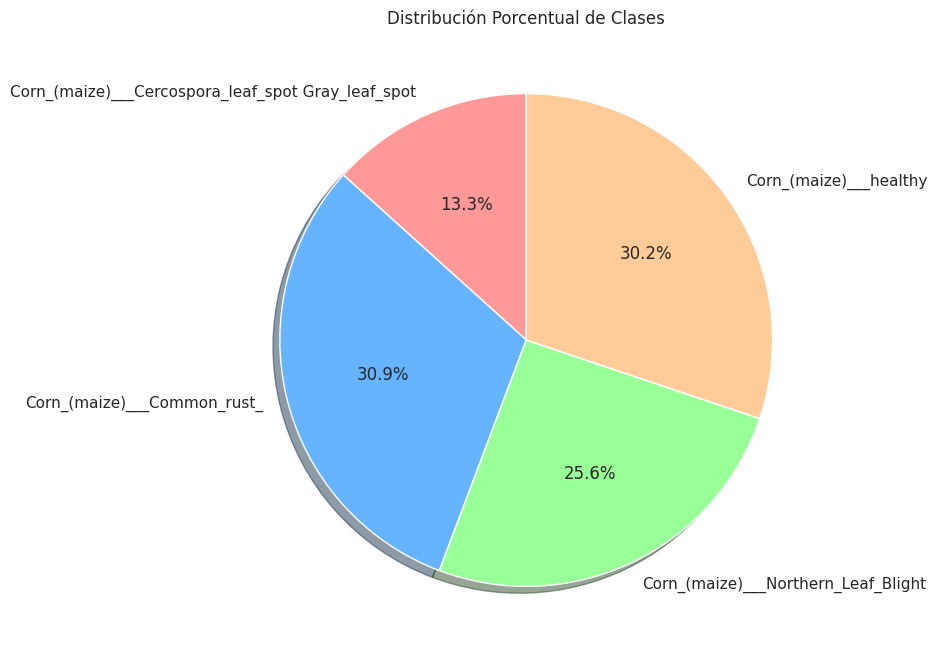


 TABLA RESUMEN DEL DATASET:
CLASE                                              IMÁGENES   %     
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 513        13.32 
Corn_(maize)___Common_rust_                        1192       30.94 
Corn_(maize)___Northern_Leaf_Blight                985        25.57 
Corn_(maize)___healthy                             1162       30.17 
TOTAL                                              3852       100%  


In [ ]:

print("\n=== VISUALIZACIÓN DE DISTRIBUCIÓN ===")

# GRÁFICO
plt.figure(figsize=(10, 6))
bars = plt.barh(df_resumen['Clase'], df_resumen['Número de Imágenes'],
                color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase - PlantVillage')
plt.grid(axis='x', alpha=0.3)

for bar, valor in zip(bars, df_resumen['Número de Imágenes']):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{valor}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.pie(df_resumen['Número de Imágenes'],
        labels=df_resumen['Clase'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        shadow=True)
plt.title('Distribución Porcentual de Clases')
plt.show()

print("\n TABLA RESUMEN DEL DATASET:")
print("="*55)
print(f"{'CLASE':<50} {'IMÁGENES':<10} {'%':<6}")
print("="*55)
for _, row in df_resumen.iterrows():
    clase_corta = row['Clase'][:48] + "..." if len(row['Clase']) > 50 else row['Clase']
    print(f"{clase_corta:<50} {row['Número de Imágenes']:<10} {row['Porcentaje']:<6}")
print("="*55)
print(f"{'TOTAL':<50} {total_imagenes:<10} {'100%':<6}")

# 5) Muestra Visual de Imagenes


=== MUESTRA VISUAL DE IMÁGENES ===

 MOSTRANDO EJEMPLOS: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot


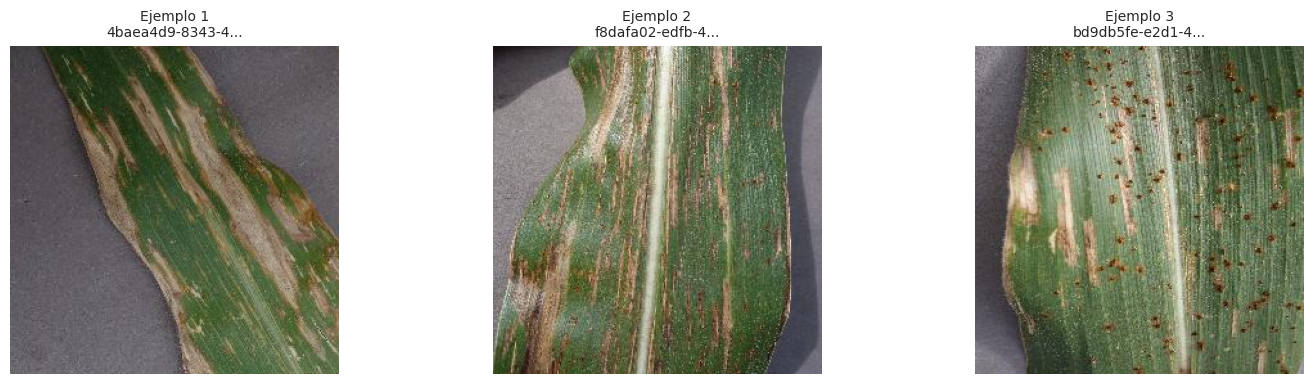


 MOSTRANDO EJEMPLOS: Corn_(maize)___Common_rust_


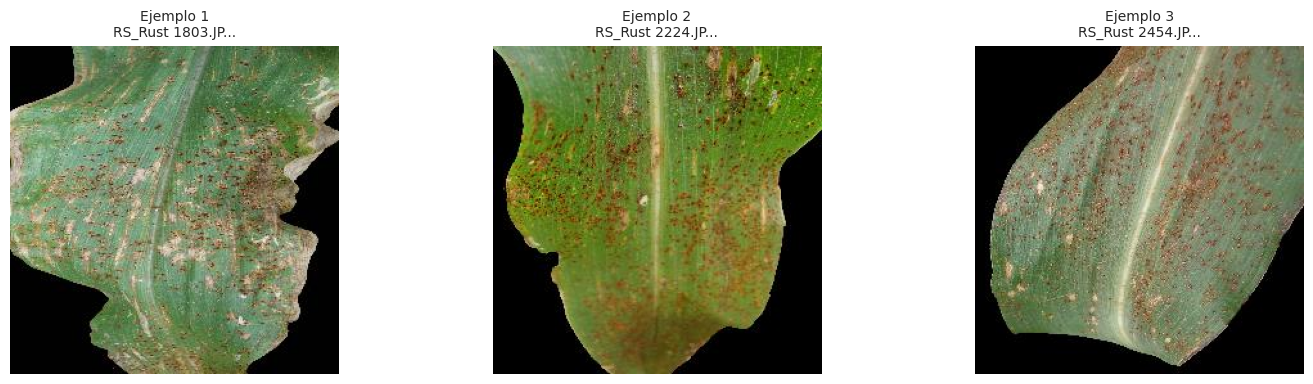


 MOSTRANDO EJEMPLOS: Corn_(maize)___Northern_Leaf_Blight


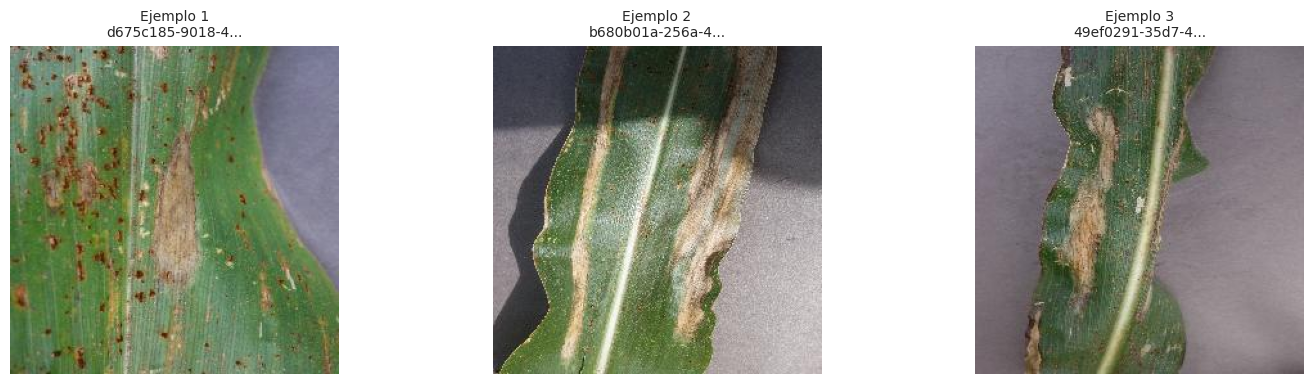


 MOSTRANDO EJEMPLOS: Corn_(maize)___healthy


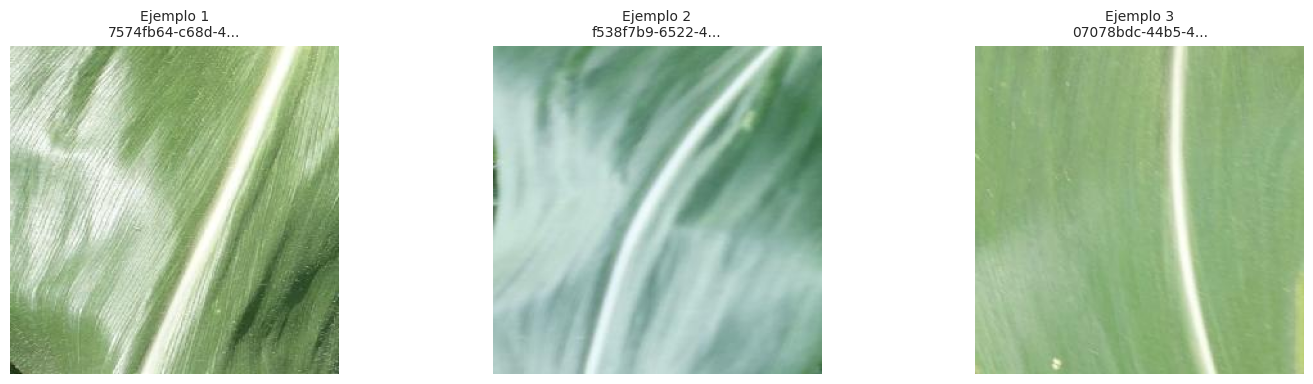

In [ ]:

print("\n=== MUESTRA VISUAL DE IMÁGENES ===")

def mostrar_ejemplos_por_clase(clase, num_ejemplos=3):
    """Ejemplos de imágenes para las clases"""
    print(f"\n MOSTRANDO EJEMPLOS: {clase}")

    folder = os.path.join(DATA_COLOR, clase)
    archivos = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png','.jpeg'))]

    # Tomar muestra aleatoria
    muestra = np.random.choice(archivos, min(num_ejemplos, len(archivos)), replace=False)

    fig, axes = plt.subplots(1, num_ejemplos, figsize=(15, 4))

    for j, archivo in enumerate(muestra):
        img_path = os.path.join(folder, archivo)
        try:
            img = Image.open(img_path)
            if num_ejemplos > 1:
                axes[j].imshow(img)
                axes[j].set_title(f'Ejemplo {j+1}\n{archivo[:15]}...', fontsize=10)
                axes[j].axis('off')
            else:
                axes.imshow(img)
                axes.set_title(f'{clase}\n{archivo[:15]}...', fontsize=10)
                axes.axis('off')
        except Exception as e:
            if num_ejemplos > 1:
                axes[j].text(0.5, 0.5, f'Error\ncargando', ha='center', va='center')
                axes[j].axis('off')
            else:
                axes.text(0.5, 0.5, f'Error\ncargando', ha='center', va='center')
                axes.axis('off')

    plt.tight_layout()
    plt.show()

# Mostrar ejemplos para cada clase
for clase in clases_corn:
    mostrar_ejemplos_por_clase(clase, num_ejemplos=3)

#6) Dimensiones de las imagenes

In [ ]:

print("\n=== ANÁLISIS DE DIMENSIONES DE IMÁGENES ===")

dimensiones = []
print(" Analizando dimensiones de muestra de imágenes...")

for clase in clases_corn:
    folder = os.path.join(DATA_COLOR, clase)
    archivos = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png','.jpeg'))]

    muestra = np.random.choice(archivos, min(5, len(archivos)), replace=False)

    for archivo in muestra:
        img_path = os.path.join(folder, archivo)
        try:
            with Image.open(img_path) as img:
                ancho, alto = img.size
                dimensiones.append((clase, ancho, alto, archivo))
        except Exception as e:
            continue

df_dimensiones = pd.DataFrame(dimensiones, columns=['Clase', 'Ancho', 'Alto', 'Archivo'])

print("\n ESTADÍSTICAS DE DIMENSIONES:")
print("="*60)
stats = df_dimensiones.groupby('Clase').agg({
    'Ancho': ['min', 'max', 'mean'],
    'Alto': ['min', 'max', 'mean']
}).round(0)

print(stats)
print("="*60)




=== ANÁLISIS DE DIMENSIONES DE IMÁGENES ===
 Analizando dimensiones de muestra de imágenes...

 ESTADÍSTICAS DE DIMENSIONES:
                                                   Ancho             Alto  \
                                                     min  max   mean  min   
Clase                                                                       
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   256  256  256.0  256   
Corn_(maize)___Common_rust_                          256  256  256.0  256   
Corn_(maize)___Northern_Leaf_Blight                  256  256  256.0  256   
Corn_(maize)___healthy                               256  256  256.0  256   

                                                                
                                                    max   mean  
Clase                                                           
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  256  256.0  
Corn_(maize)___Common_rust_                         256  256.0  
Corn_(mai

# Fase 2 del proyecto Aprendizaje Supervisado

# 7) Verificación de carpetas y detección de clases Corn


In [ ]:
# 3) Verificar que exista la ruta y detectar carpetas que empiezan con "Corn"
if not os.path.isdir(DATA_COLOR):
    raise FileNotFoundError(f"No se encontró la carpeta: {DATA_COLOR}. Por favor sube PlantVillage/color a tu Drive.")

clases_corn = [d for d in os.listdir(DATA_COLOR) if d.startswith("Corn")]
clases_corn = sorted(clases_corn)
print("Clases detectadas:", clases_corn)

if len(clases_corn) == 0:
    raise RuntimeError("No se detectaron carpetas que empiecen por 'Corn' en la ruta. Revisa la estructura.")


Clases detectadas: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']


# 8)  Carga y extraccion de features (mean / std)


In [ ]:
# 4) Cargar imágenes, extraer mean/std
data = []

for label in clases_corn:
    folder = os.path.join(DATA_COLOR, label)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png','.jpeg'))]
    print(f"Cargando {label}: {len(files)} imágenes")
    for file in tqdm(files, desc=f"Cargando {label}"):
        try:
            img_path = os.path.join(folder, file)
            img = Image.open(img_path).convert("RGB").resize((64,64))
            arr = np.array(img)/255.0
            mean = arr.mean(axis=(0,1))
            std = arr.std(axis=(0,1))
            features = np.concatenate([mean,std])
            data.append([*features, label])
        except Exception as e:
            # no interrumpimos el proceso por una imagen corrupta
            continue

columns = ['mean_R','mean_G','mean_B','std_R','std_G','std_B','label']
df = pd.DataFrame(data, columns=columns)
df['label'] = df['label'].str.strip()

print("Tamaño del dataset:", df.shape)
print("\nCantidad de imágenes por clase:")
print(df['label'].value_counts())


Cargando Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 imágenes


Cargando Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 100%|██████████| 513/513 [00:03<00:00, 144.15it/s]


Cargando Corn_(maize)___Common_rust_: 1192 imágenes


Cargando Corn_(maize)___Common_rust_: 100%|██████████| 1192/1192 [00:12<00:00, 91.70it/s] 


Cargando Corn_(maize)___Northern_Leaf_Blight: 985 imágenes


Cargando Corn_(maize)___Northern_Leaf_Blight: 100%|██████████| 985/985 [00:08<00:00, 120.49it/s]


Cargando Corn_(maize)___healthy: 1162 imágenes


Cargando Corn_(maize)___healthy: 100%|██████████| 1162/1162 [00:11<00:00, 101.28it/s]

Tamaño del dataset: (3852, 7)

Cantidad de imágenes por clase:
label
Corn_(maize)___Common_rust_                           1192
Corn_(maize)___healthy                                1162
Corn_(maize)___Northern_Leaf_Blight                    985
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     513
Name: count, dtype: int64


Distribucion de las Clases

In [ ]:


print(df.describe().T)


         count      mean       std       min       25%       50%       75%  \
mean_R  3852.0  0.437450  0.099326  0.106149  0.375077  0.437819  0.490859   
mean_G  3852.0  0.498193  0.124288  0.148910  0.418382  0.479227  0.565368   
mean_B  3852.0  0.378561  0.114039  0.036564  0.300582  0.375029  0.441460   
std_R   3852.0  0.169055  0.060201  0.036822  0.121407  0.151416  0.218831   
std_G   3852.0  0.156670  0.075201  0.032866  0.093640  0.127792  0.230169   
std_B   3852.0  0.164732  0.043657  0.033914  0.131966  0.162705  0.197038   

             max  
mean_R  0.781010  
mean_G  0.856813  
mean_B  0.771378  
std_R   0.354851  
std_G   0.369244  
std_B   0.336927  


# 9) Preparación para ML clásico: split train/test, scaling


In [ ]:
# 5) Split train/test y escalado
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=seed
)

scaler = StandardScaler() # Esto es para normalizar
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Tamaño train:", X_train.shape, " | Tamaño test:", X_test.shape)


Tamaño train: (2696, 6)  | Tamaño test: (1156, 6)


# 10) Modelos ML: Decision Tree, Random Forest, SVM


In [ ]:
# 6) Entrenamiento de modelos
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=seed),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=seed),
    "SVM": SVC(kernel='rbf', random_state=seed)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    results[name] = acc



=== Decision Tree ===
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.45      0.47      0.46       154
                       Corn_(maize)___Common_rust_       0.97      0.96      0.96       358
               Corn_(maize)___Northern_Leaf_Blight       0.72      0.70      0.71       295
                            Corn_(maize)___healthy       0.97      0.98      0.98       349

                                          accuracy                           0.83      1156
                                         macro avg       0.78      0.78      0.78      1156
                                      weighted avg       0.84      0.83      0.84      1156


=== Random Forest ===
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.52      0.35      0.42       154
                       Corn_(m

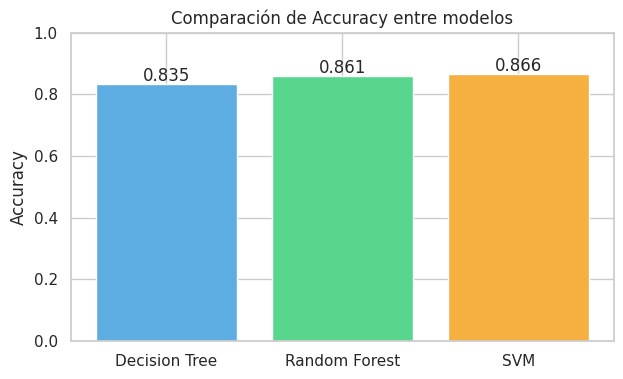

Resultados resumen:
Decision Tree: 0.835
Random Forest: 0.861
SVM: 0.866


In [ ]:
# 6b) Comparación visual de accuracies
plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color=['#5DADE2','#58D68D','#F5B041'])
plt.title("Comparación de Accuracy entre modelos")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i,(k,v) in enumerate(results.items()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()

print("Resultados resumen:")
for k,v in results.items():
    print(f"{k}: {v:.3f}")


# 11) Validación cruzada (KFold)


In [ ]:
# 7) KFold 5-fold en train
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    print(f"{name} | Accuracy promedio (5-fold): {scores.mean():.3f} ± {scores.std():.3f}")


Decision Tree | Accuracy promedio (5-fold): 0.812 ± 0.014
Random Forest | Accuracy promedio (5-fold): 0.861 ± 0.006
SVM | Accuracy promedio (5-fold): 0.872 ± 0.010


# 12) Matriz de confusión del mejor modelo


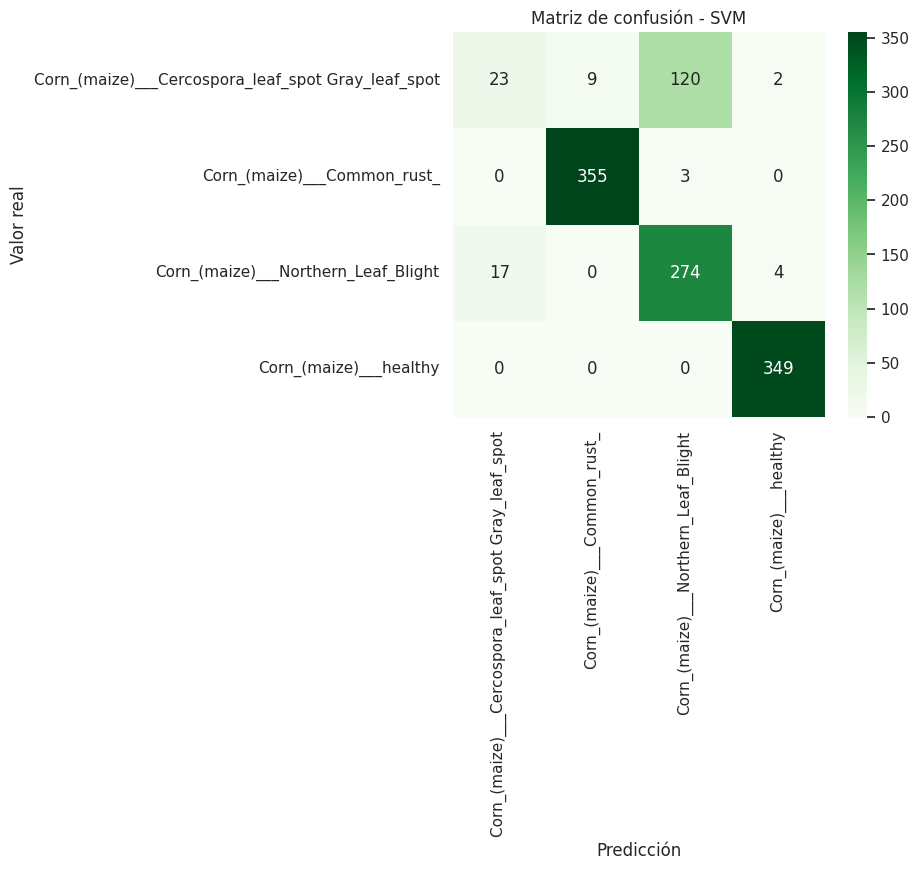

Mejor modelo: SVM


In [ ]:
# ) Matriz confusión para el mejor modelo
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

print(f"Mejor modelo: {best_model_name}")


# 13) Curvas de aprendizaje — SVM, Decision Tree, Random Forest


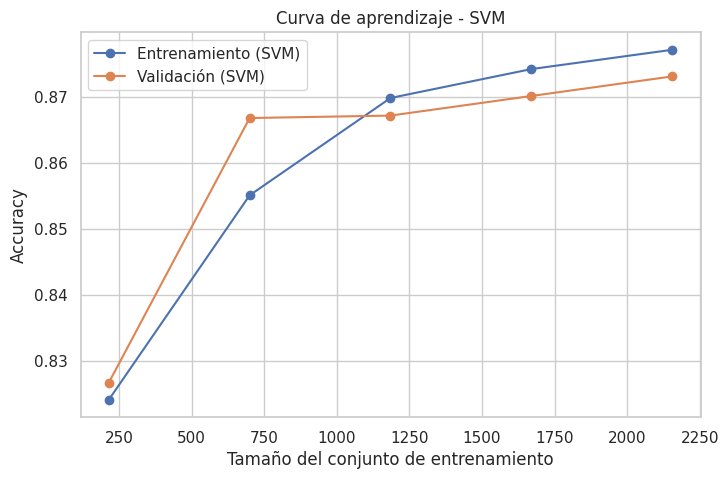

In [ ]:
# ) Curva de aprendizaje - SVM
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=seed)
train_sizes_svm, train_scores_svm, val_scores_svm = learning_curve(
    svm_classifier,
    X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy', n_jobs=-1
)
train_mean_svm = np.mean(train_scores_svm, axis=1)
val_mean_svm = np.mean(val_scores_svm, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_svm, train_mean_svm, 'o-', label="Entrenamiento (SVM)")
plt.plot(train_sizes_svm, val_mean_svm, 'o-', label="Validación (SVM)")
plt.title("Curva de aprendizaje - SVM")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


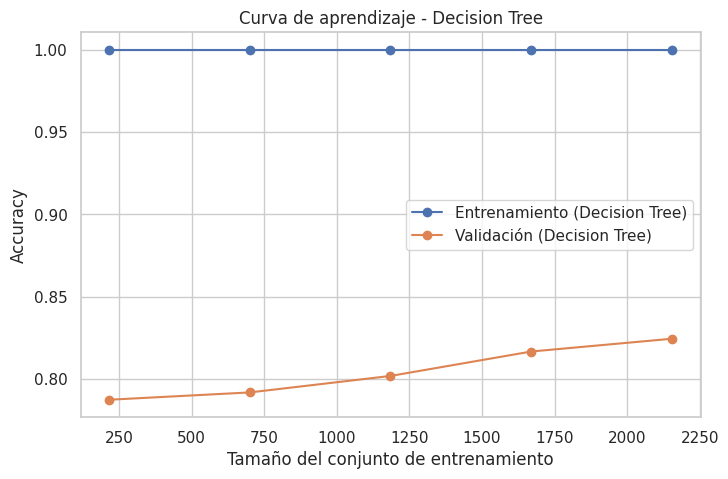

In [ ]:
# ) Curva de aprendizaje - Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=seed)
train_sizes_dt, train_scores_dt, val_scores_dt = learning_curve(
    dt_classifier,
    X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy', n_jobs=-1
)
train_mean_dt = np.mean(train_scores_dt, axis=1)
val_mean_dt = np.mean(val_scores_dt, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_dt, train_mean_dt, 'o-', label="Entrenamiento (Decision Tree)")
plt.plot(train_sizes_dt, val_mean_dt, 'o-', label="Validación (Decision Tree)")
plt.title("Curva de aprendizaje - Decision Tree")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


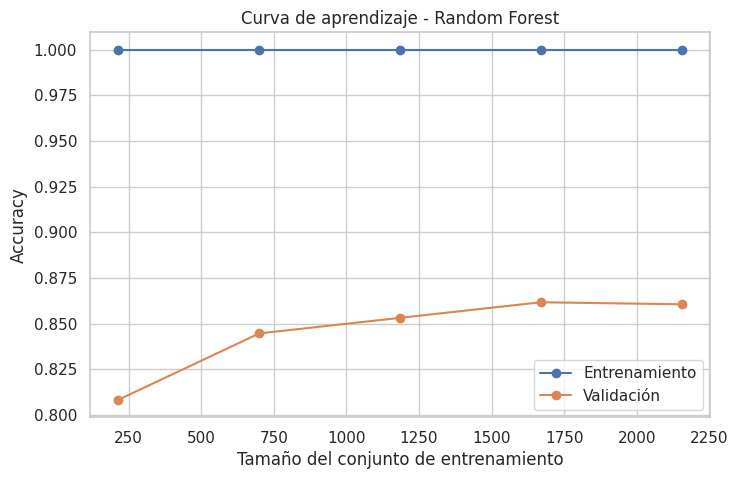

In [ ]:
# ) Curva de aprendizaje - Random Forest
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=seed),
    X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy', n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label="Entrenamiento")
plt.plot(train_sizes, val_mean, 'o-', label="Validación")
plt.title("Curva de aprendizaje - Random Forest")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# 14) Deep Learning — MLP


In [ ]:
# ) Deep Learning: reproducir tu MLP (copiado)
# Verifica que root_dir exista (si usas otra ruta edita)
root_dir = DATA_COLOR

# Orden de clases (igual que antes)
class_names_used = [
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___healthy",
    "Corn_(maize)___Northern_Leaf_Blight"
]

img_size_raw = (256, 256)   # tamaño de carga desde disco
target_size = (128, 128)    # tamaño para el MLP (reduce parámetros)
val_split = 0.2
batch = 32
num_classes = len(class_names_used)

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    root_dir,
    labels="inferred",
    label_mode="int",
    class_names=class_names_used,
    image_size=img_size_raw,
    color_mode="rgb",
    validation_split=val_split,
    subset="training",
    seed=seed,
    shuffle=True,
    batch_size=batch,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    root_dir,
    labels="inferred",
    label_mode="int",
    class_names=class_names_used,
    image_size=img_size_raw,
    color_mode="rgb",
    validation_split=val_split,
    subset="validation",
    seed=seed,
    shuffle=False,
    batch_size=batch,
)

print("Orden de clases (fijo):", class_names_used)


Found 3852 files belonging to 4 classes.
Using 3082 files for training.
Found 3852 files belonging to 4 classes.
Using 770 files for validation.
Orden de clases (fijo): ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight']


Preprocesamiento

In [ ]:
# ) Preprocesamiento para MLP
@tf.function
def preprocess_batch_for_mlp(x, y):
    x = tf.image.resize(x, target_size)
    x = tf.cast(x, tf.float32)
    maxv = tf.reduce_max(x, axis=[1,2,3], keepdims=True)
    x = tf.where(maxv > 1.0, x / 255.0, x)
    x = tf.reshape(x, (tf.shape(x)[0], -1))
    return x, tf.cast(y, tf.int32)

train_ds_pp = train_ds_raw.map(preprocess_batch_for_mlp, num_parallel_calls=tf.data.AUTOTUNE).cache().shuffle(8192, seed=seed).prefetch(tf.data.AUTOTUNE)
val_ds_pp   = val_ds_raw.map(preprocess_batch_for_mlp,   num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)


#15) Definicion del MLP

In [ ]:
# Definición del MLP
reg = tf.keras.regularizers.l2(1e-4)
inputs = tf.keras.Input(shape=(target_size[0]*target_size[1]*3,))
x = tf.keras.layers.BatchNormalization()(inputs)
x = tf.keras.layers.Dense(1024, activation="relu", kernel_regularizer=reg)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(512, activation="relu", kernel_regularizer=reg)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]


#16) Estimar los class weights

In [ ]:
# ) Estimar class weights
counts = np.zeros(num_classes, dtype=np.int64)
for _, yb in train_ds_raw.unbatch().batch(4096):
    y_np = yb.numpy()
    for i in range(num_classes):
        counts[i] += np.sum(y_np == i)
class_weights = {i: float(np.sum(counts)/max(counts[i],1)) for i in range(num_classes)}
print("Distribución clases (train):", dict(zip(class_names_used, counts.tolist())))
print("Class weights:", class_weights)


Distribución clases (train): {'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 427, 'Corn_(maize)___Common_rust_': 942, 'Corn_(maize)___healthy': 950, 'Corn_(maize)___Northern_Leaf_Blight': 763}
Class weights: {0: 7.217798594847775, 1: 3.2717622080679405, 2: 3.2442105263157894, 3: 4.039318479685452}


#17) Entrenamineto del MLP

In [ ]:
#  Entrenamiento del MLP
history = model.fit(
    train_ds_pp,
    validation_data=val_ds_pp,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1,
)


Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.7046 - loss: 3.4686 - val_accuracy: 0.0714 - val_loss: 2.4889 - learning_rate: 0.0010
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8361 - loss: 2.2369 - val_accuracy: 0.9260 - val_loss: 0.8737 - learning_rate: 0.0010
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8700 - loss: 1.9082 - val_accuracy: 0.9026 - val_loss: 0.7975 - learning_rate: 0.0010
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8921 - loss: 1.8059 - val_accuracy: 0.8519 - val_loss: 0.8841 - learning_rate: 0.0010
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9033 - loss: 1.5941 - val_accuracy: 0.7753 - val_loss: 1.0148 - learning_rate: 0.0010
Epoch 6/10
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9209 - loss: 1.4657
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9207 - loss: 1.4668 - val_ac

#18) Envolver modelo para inferencia

In [ ]:
#  Envolver modelo para inferencia
TARGET_SIZE = (128, 128)
inp = keras.Input(shape=(None, None, 3))
z = layers.Resizing(TARGET_SIZE[0], TARGET_SIZE[1])(inp)
z = layers.Rescaling(1./255)(z)
z = layers.Flatten()(z)
out = model(z)
model_infer = keras.Model(inp, out)
model_infer.compile(
    optimizer=model.optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

test_loss, test_acc = model_infer.evaluate(val_ds_raw, verbose=1)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.8994 - loss: 0.7449
Test loss: 0.7363490462303162
Test accuracy: 0.9142857193946838


#19) Evaluar el modelo

In [ ]:
# ======================== EVALUACIÓN =========================

# ============== PREDICCIÓN DE UNA IMAGEN EXTERNA =============
def predict_external_image(image_path: str):
    raw = tf.io.read_file(image_path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)  # RGB
    probs = model_infer.predict(img[None, ...], verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_name = class_names_used[pred_idx]

    plt.imshow(img.numpy().astype(np.uint8)); plt.axis('off')
    plt.title(f"Pred: {pred_name} (p={probs[pred_idx]:.2f})")
    plt.show()
    return pred_name, probs

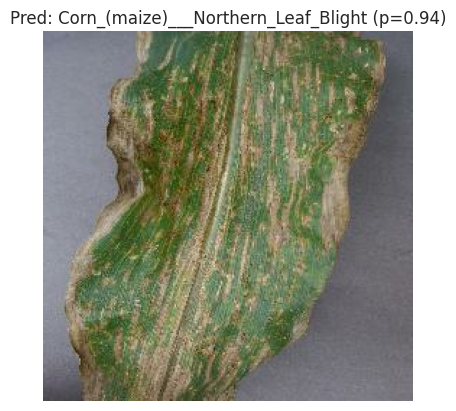

('Corn_(maize)___Northern_Leaf_Blight',
 array([6.3933693e-02, 2.3778217e-05, 8.7620774e-06, 9.3603373e-01],
       dtype=float32))

In [ ]:

vegetable_leaf = "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot"
specific_img = "00a20f6f-e8bd-4453-9e25-36ea70feb626___RS_GLSp 4655.JPG"
early_blight = os.path.join(DATA_COLOR, vegetable_leaf, specific_img)
# Ejecuta
predict_external_image(early_blight)

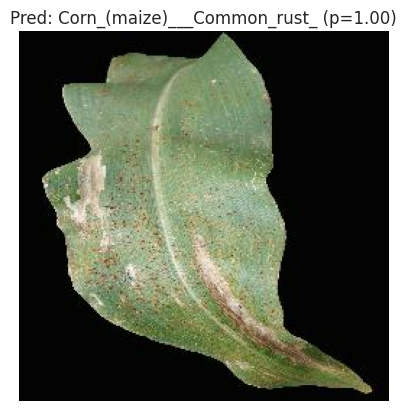

('Corn_(maize)___Common_rust_',
 array([1.2537784e-05, 9.9997747e-01, 3.0855153e-06, 6.9078496e-06],
       dtype=float32))

In [ ]:
# dataset_path = "plantvillage dataset/color" # This path is incorrect
vegetable_leaf = "Corn_(maize)___Common_rust_"
specific_img = "RS_Rust 1563.JPG"

late_blight = os.path.join(DATA_COLOR, vegetable_leaf, specific_img) # Use the correct DATA_COLOR path

predict_external_image(late_blight)

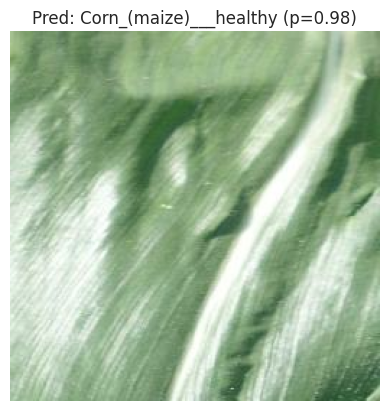

('Corn_(maize)___healthy',
 array([9.0783695e-03, 6.2585801e-05, 9.8183471e-01, 9.0243630e-03],
       dtype=float32))

In [ ]:

vegetable_leaf = "Corn_(maize)___healthy"
specific_img = "254d1f23-8a22-4f21-9d5e-0c66733f102f___R.S_HL 8083 copy.jpg"

late_blight_2 = os.path.join(DATA_COLOR, vegetable_leaf, specific_img)

predict_external_image(late_blight_2)


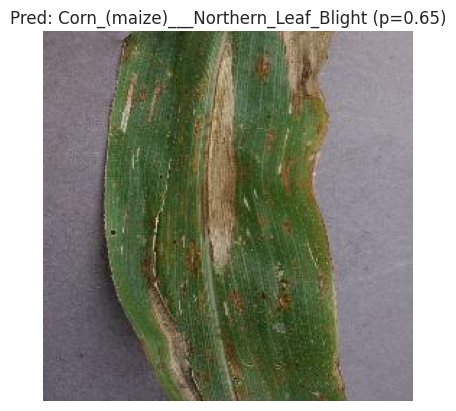

('Corn_(maize)___Northern_Leaf_Blight',
 array([3.5193893e-01, 1.4318853e-04, 1.5664754e-04, 6.4776123e-01],
       dtype=float32))

In [ ]:

vegetable_leaf = "Corn_(maize)___Northern_Leaf_Blight"
specific_img = "00a14441-7a62-4034-bc40-b196aeab2785___RS_NLB 3932.JPG"

Healthy = os.path.join(DATA_COLOR, vegetable_leaf, specific_img)

predict_external_image(Healthy)